# Data Preparation

## Import Libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load DataSets

In [44]:
sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

## Basic Exploration

In [45]:
sentiment.head(2)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02


In [46]:
trades.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12


In [47]:
sentiment.tail(2)

,timestamp,value,classification,date
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


In [48]:
trades.tail(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [49]:
sentiment.sample(2)

,timestamp,value,classification,date
483,1559453400,63,Greed,2019-06-02
1610,1656826200,11,Extreme Fear,2022-07-03


In [50]:
trades.sample(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
30232,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,kBONK,0.041891,9901.0,414.76,BUY,04-03-2024 21:53,-1015804.0,Close Short,15.514867,0x8f25a79693f03767e4290407e47d8202023c00e7ad68...,11985844300,False,-0.008295,8.810000e+14,1.710000e+12
144155,0x39cef799f8b69da1995852eea189df24eb5cae3c,XRP,1.863600,1067.0,1988.46,SELL,07-04-2025 20:05,351839.0,Close Long,-32.756900,0x97bee11bed7bf30da3cd042115eea402034100083733...,84685119949,False,0.198846,1.840000e+14,1.740000e+12


In [51]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [52]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [53]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [54]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [55]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


## Convert Dates

In [56]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['Timestamp IST']).dt.normalize()

In [57]:
sentiment.head(2)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02


In [58]:
trades.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02


## Align Datasets

In [59]:
merged = trades.merge(sentiment, on='date', how='left')

In [60]:
merged.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [61]:
merged.shape

(211224, 20)

## Feature Engineering

In [62]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [63]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['win'].mean().reset_index()
win_rate

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.455215
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.327668
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,0.475904
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236


In [64]:
avg_size = merged.groupby('Account')['Size USD'].mean().reset_index()
avg_size

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753


In [65]:
trades_per_day = merged.groupby('date').size().reset_index(name='num_trades')
trades_per_day

,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3
...,...,...
475,2025-04-27,337
476,2025-04-28,1379
477,2025-04-29,2243
478,2025-04-30,1113


In [66]:
long_short = merged.groupby(['date', 'Side']).size().unstack().fillna(0)
long_short['ratio'] = long_short['BUY'] / (long_short['SELL'] + 1)
long_short

Side,BUY,SELL,ratio
date,,,
2023-05-01,3.0,0.0,3.000000
2023-12-05,7.0,2.0,2.333333
2023-12-14,5.0,6.0,0.714286
2023-12-15,2.0,0.0,2.000000
2023-12-16,3.0,0.0,3.000000
...,...,...,...
2025-04-27,209.0,128.0,1.620155
2025-04-28,652.0,727.0,0.895604
2025-04-29,1105.0,1138.0,0.970149


In [67]:
merged['Size USD'].describe()

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64

# Analysis

## Performance Analysis

In [68]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()
pnl_sentiment

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

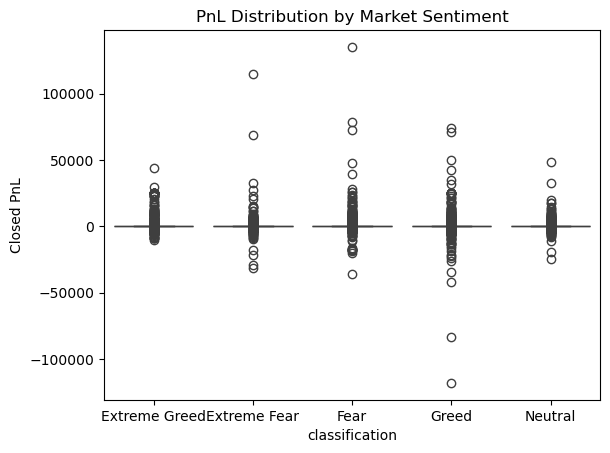

In [69]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

In [70]:
win_sentiment = merged.groupby('classification')['win'].mean()
win_sentiment

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

Text(0.5, 1.0, 'Win Rate by Sentiment')

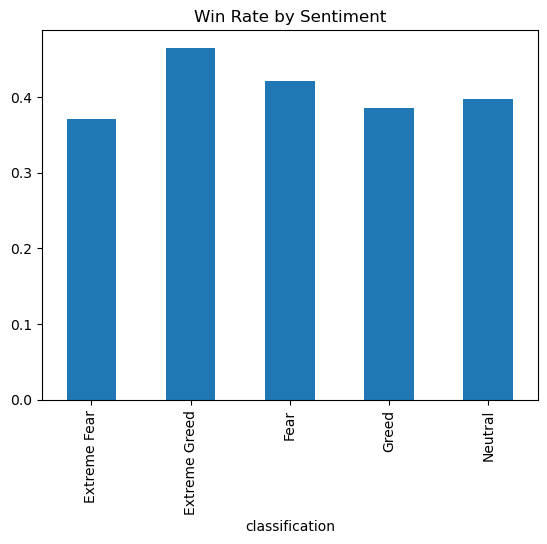

In [71]:
win_sentiment.plot(kind='bar')
plt.title("Win Rate by Sentiment")

## Behavioral Analysis

In [72]:
trades_sentiment = merged.groupby('classification').size()
trades_sentiment

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

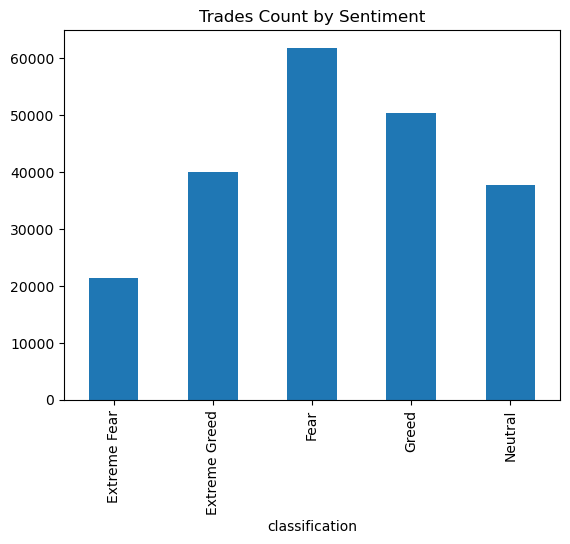

In [73]:
trades_sentiment.plot(kind='bar', title='Trades Count by Sentiment')
plt.show()

In [74]:
size_sentiment = merged.groupby('classification')['Size USD'].mean()
print(size_sentiment)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


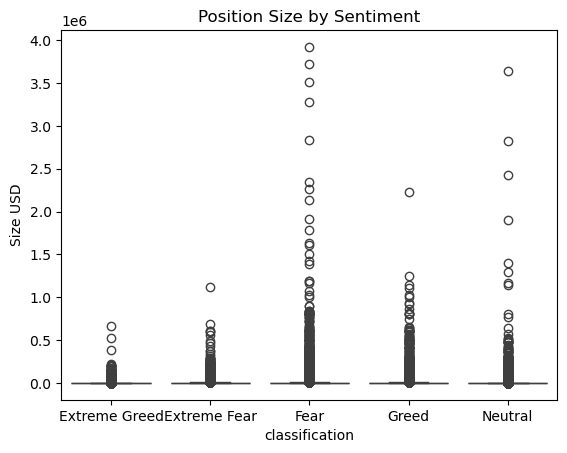

In [75]:
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Position Size by Sentiment")
plt.show()

In [76]:
side_sentiment = merged.groupby(['classification', 'Side']).size().unstack()
print(side_sentiment)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


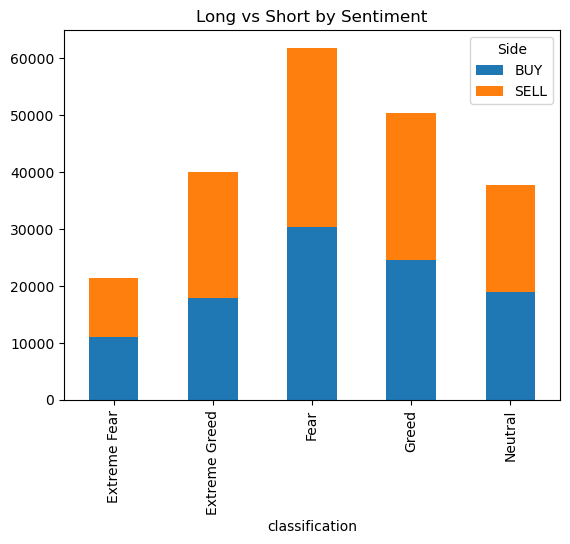

In [77]:
side_sentiment.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.show()

## Segmentation Analysis

In [78]:
median_size = merged['Size USD'].median()

merged['risk_group'] = merged['Size USD'].apply(
    lambda x: 'High Risk' if x > median_size else 'Low Risk'
)

In [79]:
merged.groupby(['risk_group', 'classification'])['Closed PnL'].mean()

risk_group  classification
High Risk   Extreme Fear       61.196379
            Extreme Greed     140.570044
            Fear               97.025581
            Greed              84.301244
            Neutral            69.581271
Low Risk    Extreme Fear        1.157202
            Extreme Greed       9.628661
            Fear                3.580906
            Greed               3.609685
            Neutral             2.188668
Name: Closed PnL, dtype: float64

Text(0.5, 1.0, 'PnL by Risk Group')

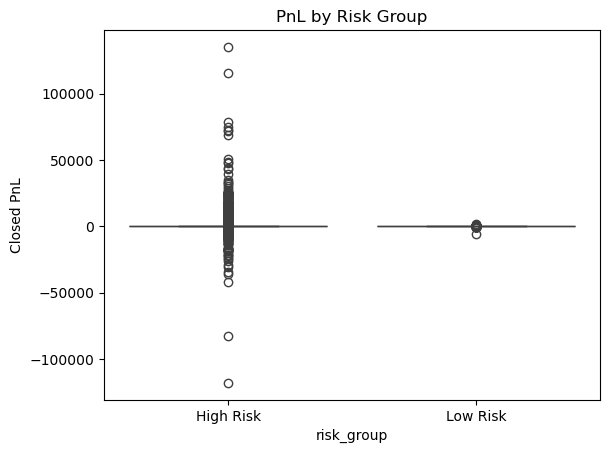

In [84]:
sns.boxplot(x='risk_group', y='Closed PnL', data=merged)
plt.title("PnL by Risk Group")

In [80]:
trade_counts = merged['Account'].value_counts()

frequent_traders = trade_counts[trade_counts > 50].index

merged['trader_type'] = merged['Account'].apply(
    lambda x: 'Frequent' if x in frequent_traders else 'Infrequent'
)

In [81]:
merged.groupby(['trader_type', 'classification'])['Closed PnL'].mean()

trader_type  classification
Frequent     Extreme Fear      34.537862
             Extreme Greed     67.892861
             Fear              54.290400
             Greed             42.743559
             Neutral           34.307718
Name: Closed PnL, dtype: float64

In [82]:
total_pnl = merged.groupby('Account')['Closed PnL'].sum()

winners = total_pnl[total_pnl > 0].index

merged['performance'] = merged['Account'].apply(
    lambda x: 'Winner' if x in winners else 'Loser'
)

In [83]:
merged.groupby(['performance', 'classification'])['Size USD'].mean()

performance  classification
Loser        Extreme Fear      5028.002691
             Extreme Greed     3088.967992
             Fear              4652.468351
             Greed             5904.680349
             Neutral           4392.164937
Winner       Extreme Fear      5369.165361
             Extreme Greed     3112.406288
             Fear              8027.263141
             Greed             5728.862967
             Neutral           4799.801341
Name: Size USD, dtype: float64

## Insights

> Performance: Trader profitability differs across sentiment regimes, with [Fear/Greed] showing lower average PnL and reduced win rates.

> Behavior: Traders increase position sizes during Greed periods, indicating higher risk appetite and potential overconfidence.

> Segments: High-risk traders (large position sizes) experience more volatile outcomes, especially during Fear periods.

> Frequent traders tend to overtrade during Greed phases, which may reduce overall profitability.

> Due to absence of leverage data, position size (USD) was used as a proxy for trader risk exposure.

# Strategy Ideas

## Strategy 1 — Risk Control During Fear

#### Insight Behind It:

> Lower PnL and win rate during Fear periods

> Higher volatility, especially for high-risk (large position size) traders

#### Strategy Rule:

>During Fear market conditions, traders should reduce position sizes and avoid aggressive trades, especially high-risk traders.

#### Practical Implementation:

>Reduce position size by 30–50%

>Avoid consecutive trades after losses

>Focus only on high-confidence setups

#### Why it works:

>Fear markets are unstable → high probability of losses

>Smaller exposure = capital preservation

## Strategy 2 — Control Overtrading During Greed

#### Insight Behind It:

>Increased trade frequency during Greed

>Larger position sizes → overconfidence behavior

#### Strategy Rule:

>During Greed periods, traders should limit the number of trades and avoid impulsive entries, especially frequent traders.

#### Practical Implementation:

>Set a daily trade limit (e.g., max 5 trades/day)

>Avoid increasing position size after wins

>Use strict entry criteria

#### Why it works:

>Greed leads to overtrading + emotional decisions

>Discipline improves long-term profitability

## Strategy 3 — Segment-Based Strategy (High vs Low Risk)

#### Insight Behind It:

>High-risk traders (large positions) show higher volatility

>Low-risk traders are more stable

#### Strategy Rule:

>High-risk traders should adopt dynamic position sizing based on sentiment, while low-risk traders can maintain consistency.

#### Practical Implementation:

>High-risk traders:

>>Reduce size in Fear

>>Slightly increase in Greed (controlled)

>Low-risk traders:

>>Maintain steady position sizing

#### Why it works:

>Matches risk-taking with market conditions

>Reduces drawdowns while allowing upside

# Conclusion

> This analysis shows that trader behavior is significantly influenced by market sentiment. Fear leads to risk-averse or unstable performance, while Greed encourages overtrading and larger positions. By adapting strategies based on sentiment and trader type, traders can improve consistency and reduce risk exposure.

> Due to absence of leverage data, position size (USD) was used as a proxy for trader risk exposure.